Что нашел:
1. Таргет SI считается как отношение CC50 к IC50. Можно было бы обучить модели на CC50 и IC50, а SI посчитать, но по условиям хакатона для SI тоже нужна модель;
2. Длинные хвосты у таргетов;
3. Дубликаты признаков с разными таргетами;
4. Константные признаки, которые нужно удалить;
5. Между признаками много корреляций. Линейные модели без регуляризации не подойдут.

Предлагаю:
1. Удалить index из признаков;
2. Заполнять пропуски медианой;
3. Удалить константные признаки через `VarianceThreshold`;
4. Обучать модели на логарифмированных таргетах;
5. Схлопнуть дубликаты признаков в одну строку, а таргеты агрегировать через медиану;
6. Использовать `GroupKFold`, чтобы дубликаты не попали в обучение и проверку;
7. Сравнить минимум несколько моделей: линейные с регуляризацией, пару деревьев и бустинги (как минимум catboost и lgbm);
8. Для feature engineering использовать простые отношения и агрегации.

## Загрузка библиотек и данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import spearmanr, ks_2samp

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 100)

In [2]:
train_path = Path("datasets/train.csv")
test_path = Path("datasets/test.csv")

if not train_path.exists():
    train_path = Path("/mnt/data/train.csv")
if not test_path.exists():
    test_path = Path("/mnt/data/test.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

target_cols = ["IC50, mM", "CC50, mM", "SI"]
id_col = "index"

feature_cols = [col for col in train.columns if col not in target_cols + [id_col]]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Number of features:", len(feature_cols))

print()
print("Типы данных в train:")
display(train.dtypes.value_counts())

display(train.head())

Train shape: (751, 214)
Test shape: (250, 211)
Number of features: 210

Типы данных в train:


int64      107
float64    107
Name: count, dtype: int64

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1.789178e+03,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,11.761885,18.199101,12.132734,11.440240,12.483670,4.736863,17.449271,0.0,0.000000,0.000000,0.000000,29.867250,30.331835,0,0.000000,4.899910,5.687386,0.000000,11.761885,24.967341,4.736863,0.000000,0.000000,30.331835,0.000000,0.000000,0,12.47,0.000000,0.000000,0.0,0.000000,0.000000,24.967341,5.687386,0.000000,17.828252,29.165378,4.736863,5.466584,1.919608,2.247685,0.000000,1.247130,2.132289,10.398397,0.000000,1.588307,0.000000,0.400000,13,0,2,0,1,1,1,0,1,3,0,3,1,0,1,1,2,2.1714,57.0650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.46

## EDA

In [3]:
print("Train missing values:", train.isna().sum().sum())
print("Test missing values:", test.isna().sum().sum())

missing_train = train.isna().sum()
missing_test = test.isna().sum()

display(missing_train[missing_train > 0].sort_values(ascending=False))
display(missing_test[missing_test > 0].sort_values(ascending=False))

Train missing values: 24
Test missing values: 12


MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64

MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64

In [4]:
si_check = train["CC50, mM"] / train["IC50, mM"]
diff = (train["SI"] - si_check).abs()

print("Максимальное отличие:", diff.max())
print("Среднее отличие:", diff.mean())

Максимальное отличие: 2.000888343900442e-11
Среднее отличие: 5.927786649615066e-14


,count,mean,std,min,25%,50%,75%,max
"IC50, mM",751.0,204.544021,370.367937,0.003517,13.222351,44.069306,206.787402,4095.188563
"CC50, mM",751.0,577.426098,641.515163,0.700808,99.998894,376.580899,877.508784,4538.976189
SI,751.0,89.153313,788.882198,0.011489,1.500000,4.000000,17.372463,15620.600000


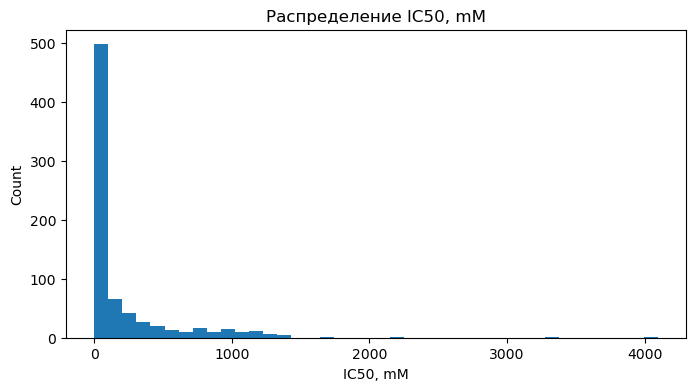

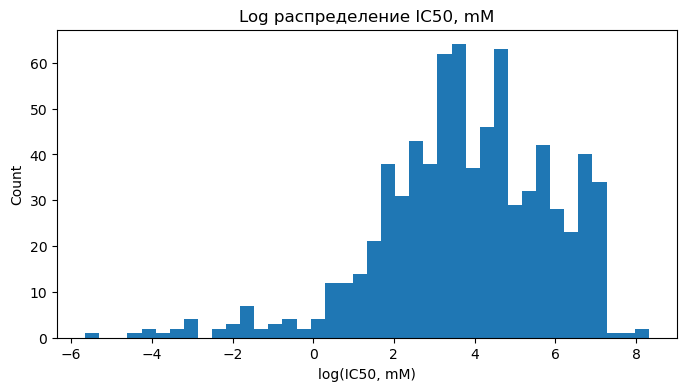

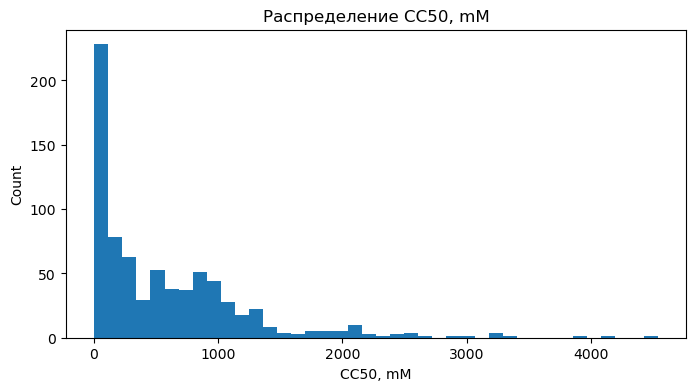

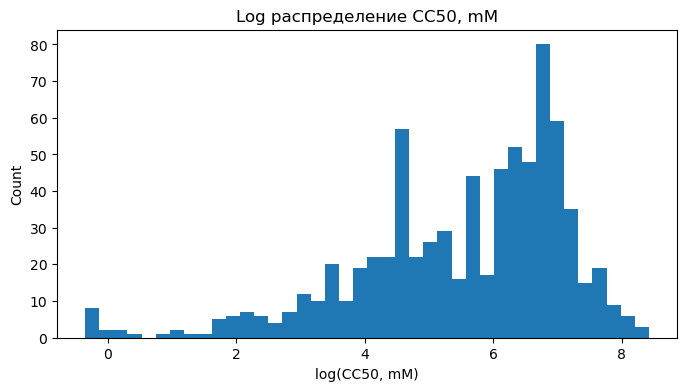

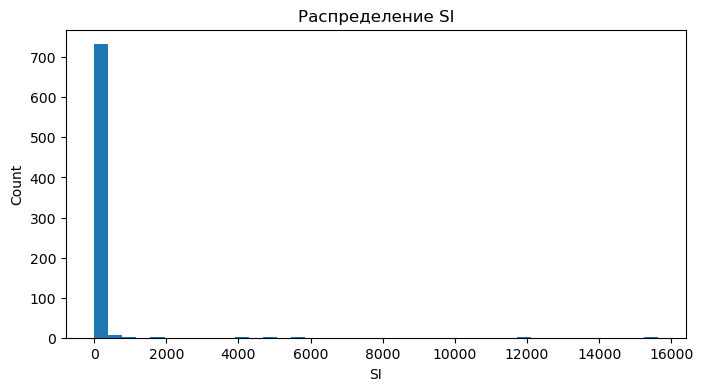

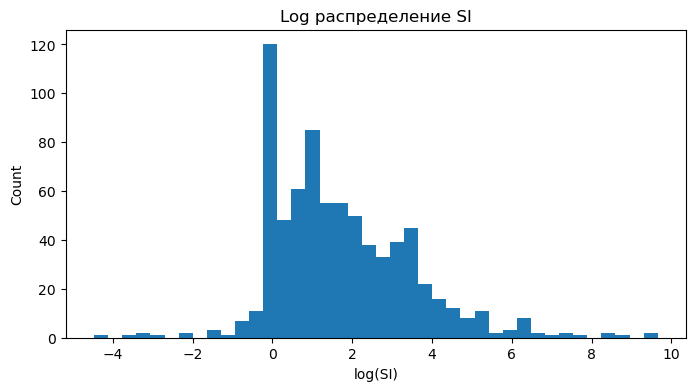

In [18]:
display(train[target_cols].describe().T)

for col in target_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(train[col], bins=40)
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(np.log(train[col]), bins=40)
    plt.title(f"Log распределение {col}")
    plt.xlabel(f"log({col})")
    plt.ylabel("Count")
    plt.show()

In [6]:
# Константные признаки

nunique = train[feature_cols].nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()

print("Количество константных признаков:", len(constant_cols))
constant_cols

Количество константных признаков: 18


['NumRadicalElectrons',
 'SMR_VSA8',
 'SlogP_VSA9',
 'fr_N_O',
 'fr_SH',
 'fr_azide',
 'fr_barbitur',
 'fr_benzodiazepine',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_lactam',
 'fr_nitroso',
 'fr_phos_acid',
 'fr_phos_ester',
 'fr_prisulfonamd',
 'fr_thiocyan']

In [7]:
# Доля нулей в признаках

zero_frac = (train[feature_cols] == 0).mean().sort_values(ascending=False)

display(zero_frac.head(60))

high_zero_cols = zero_frac[zero_frac > 0.95].index.tolist()
print("Признаков с долей нулей > 95%:", len(high_zero_cols))

fr_prisulfonamd           1.000000
NumRadicalElectrons       1.000000
fr_isothiocyan            1.000000
fr_isocyan                1.000000
SlogP_VSA9                1.000000
fr_benzodiazepine         1.000000
fr_barbitur               1.000000
SMR_VSA8                  1.000000
fr_dihydropyridine        1.000000
fr_phos_ester             1.000000
fr_phos_acid              1.000000
fr_SH                     1.000000
fr_nitroso                1.000000
fr_azide                  1.000000
fr_lactam                 1.000000
fr_thiocyan               1.000000
fr_diazo                  1.000000
fr_N_O                    1.000000
fr_oxazole                0.998668
fr_HOCCN                  0.998668
fr_term_acetylene         0.998668
fr_tetrazole              0.998668
fr_Ar_COO                 0.998668
fr_hdrzine                0.997337
fr_aldehyde               0.997337
fr_epoxide                0.997337
fr_guanido                0.996005
fr_nitrile                0.994674
fr_amidine          

Признаков с долей нулей > 95%: 53


In [8]:
# Дубликаты по признакам

X = train[feature_cols].copy()
X_test = test[feature_cols].copy()

train_hash = pd.util.hash_pandas_object(X, index=False)
test_hash = pd.util.hash_pandas_object(X_test, index=False)

print("Дубликатов по признакам в train:", X.duplicated().sum())
print("Дубликатов по признакам в test:", X_test.duplicated().sum())

test_matches = test_hash.isin(set(train_hash))
print("Строк test, которые точно совпадают с train по признакам:", test_matches.sum())

Дубликатов по признакам в train: 121
Дубликатов по признакам в test: 24
Строк test, которые точно совпадают с train по признакам: 68


In [9]:
# Корреляции признаков с логарифмами таргетов

log_targets = np.log(train[target_cols])

corr_rows = []

for feature in feature_cols:
    x = train[feature]

    for target in target_cols:
        y = log_targets[target]
        mask = x.notna() & y.notna()

        if x[mask].nunique() > 1:
            corr = spearmanr(x[mask], y[mask]).correlation
        else:
            corr = np.nan

        corr_rows.append({
            "feature": feature,
            "target": target,
            "spearman_corr": corr,
            "abs_corr": abs(corr) if pd.notna(corr) else np.nan,
        })

corr_df = pd.DataFrame(corr_rows)

for target in target_cols:
    print(target)
    display(
        corr_df[corr_df["target"] == target]
        .sort_values("abs_corr", ascending=False)
        .head(20)
    )

IC50, mM


,feature,target,spearman_corr,abs_corr
360,NumSaturatedHeterocycles,"IC50, mM",0.281584,0.281584
234,SlogP_VSA5,"IC50, mM",-0.244430,0.244430
426,fr_NH2,"IC50, mM",-0.237659,0.237659
330,NumAliphaticHeterocycles,"IC50, mM",0.234275,0.234275
297,VSA_EState4,"IC50, mM",-0.229250,0.229250
309,VSA_EState8,"IC50, mM",-0.220592,0.220592
327,NumAliphaticCarbocycles,"IC50, mM",-0.217191,0.217191
279,EState_VSA8,"IC50, mM",-0.214811,0.214811
354,NumRotatableBonds,"IC50, mM",-0.211965,0.211965
270,EState_VSA5,"IC50, mM",-0.208346,0.208346


CC50, mM


,feature,target,spearman_corr,abs_corr
136,Kappa3,"CC50, mM",-0.292102,0.292102
133,Kappa2,"CC50, mM",-0.291328,0.291328
130,Kappa1,"CC50, mM",-0.284115,0.284115
28,NumValenceElectrons,"CC50, mM",-0.269125,0.269125
88,Chi0,"CC50, mM",-0.268556,0.268556
49,FpDensityMorgan2,"CC50, mM",0.267919,0.267919
373,MolMR,"CC50, mM",-0.266274,0.266274
91,Chi0n,"CC50, mM",-0.265090,0.265090
94,Chi0v,"CC50, mM",-0.262846,0.262846
139,LabuteASA,"CC50, mM",-0.262113,0.262113


SI


,feature,target,spearman_corr,abs_corr
359,NumSaturatedCarbocycles,SI,0.214443,0.214443
419,fr_Imine,SI,0.205546,0.205546
11,MinEStateIndex,SI,0.203196,0.203196
206,SMR_VSA7,SI,-0.198946,0.198946
317,FractionCSP3,SI,0.198461,0.198461
362,NumSaturatedHeterocycles,SI,-0.195322,0.195322
332,NumAliphaticHeterocycles,SI,-0.192211,0.192211
5,MaxEStateIndex,SI,-0.190158,0.190158
2,MaxAbsEStateIndex,SI,-0.190158,0.190158
329,NumAliphaticCarbocycles,SI,0.187511,0.187511


In [10]:
# Train/test drift

drift_rows = []

for feature in feature_cols:
    train_values = train[feature].dropna()
    test_values = test[feature].dropna()

    if train_values.nunique() > 1 or test_values.nunique() > 1:
        ks_stat, p_value = ks_2samp(train_values, test_values)
    else:
        ks_stat, p_value = np.nan, np.nan

    drift_rows.append({
        "feature": feature,
        "ks_stat": ks_stat,
        "p_value": p_value,
        "train_mean": train_values.mean(),
        "test_mean": test_values.mean(),
    })

drift_df = pd.DataFrame(drift_rows)

display(
    drift_df
    .sort_values("ks_stat", ascending=False)
    .head(30)
)

,feature,ks_stat,p_value,train_mean,test_mean
33,Chi1n,0.116607,0.011005,8.745933e+00,8.320018e+00
9,NumValenceElectrons,0.108676,0.021537,1.336272e+02,1.275760e+02
34,Chi1v,0.107212,0.024649,9.046804e+00,8.609390e+00
29,Chi0,0.105944,0.027122,1.786527e+01,1.707295e+01
17,FpDensityMorgan3,0.103004,0.034929,2.408121e+00,2.450633e+00
46,LabuteASA,0.099393,0.044775,1.484664e+02,1.413320e+02
30,Chi0n,0.098003,0.049955,1.468173e+01,1.405107e+01
7,HeavyAtomMolWt,0.094136,0.065685,3.283898e+02,3.126908e+02
44,Kappa2,0.092724,0.073019,6.482013e+00,6.063237e+00
31,Chi0v,0.092671,0.073576,1.501630e+01,1.437026e+01


Максимальная разница между SI и CC50 / IC50: 2.000888343900442e-11
Средняя разница между SI и CC50 / IC50: 5.927786649615066e-14


,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.598308,-0.664519
"CC50, mM",0.598308,1.000000,0.201177
SI,-0.664519,0.201177,1.000000


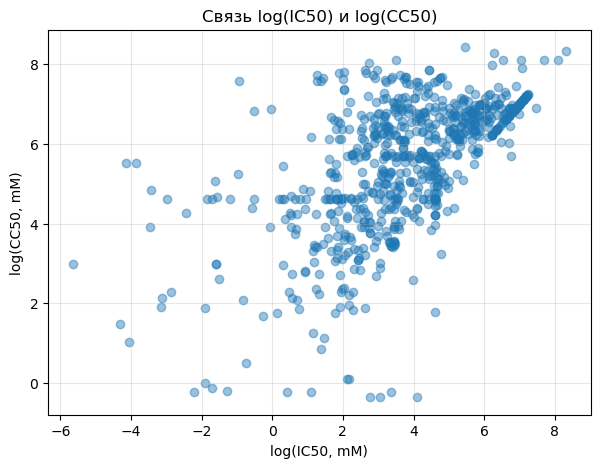

In [11]:
# Связь между таргетами

target_ratio_check = train["CC50, mM"] / train["IC50, mM"]
si_diff = (train["SI"] - target_ratio_check).abs()

print("Максимальная разница между SI и CC50 / IC50:", si_diff.max())
print("Средняя разница между SI и CC50 / IC50:", si_diff.mean())

log_target_corr = np.log(train[target_cols]).corr()
display(log_target_corr)

plt.figure(figsize=(7, 5))
plt.scatter(
    np.log(train["IC50, mM"]),
    np.log(train["CC50, mM"]),
    alpha=0.45,
)
plt.title("Связь log(IC50) и log(CC50)")
plt.xlabel("log(IC50, mM)")
plt.ylabel("log(CC50, mM)")
plt.grid(True, alpha=0.3)
plt.show()

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
"IC50, mM",0.043606,1.329394,13.222351,44.069306,206.787402,1002.304418,1334.274334
"CC50, mM",0.845548,9.834099,99.998894,376.580899,877.508784,1883.480370,3162.007168
SI,0.229697,0.941805,1.500000,4.000000,17.372463,138.433453,1281.250000


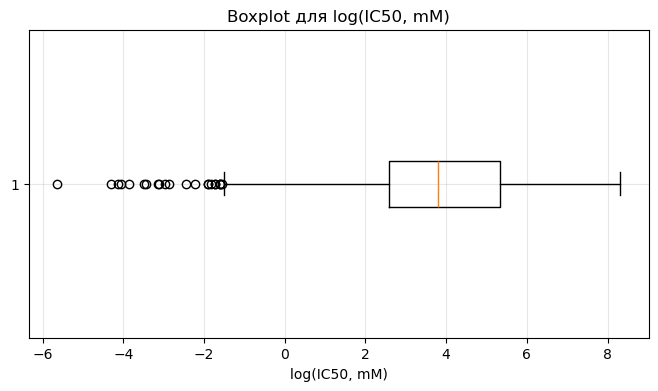

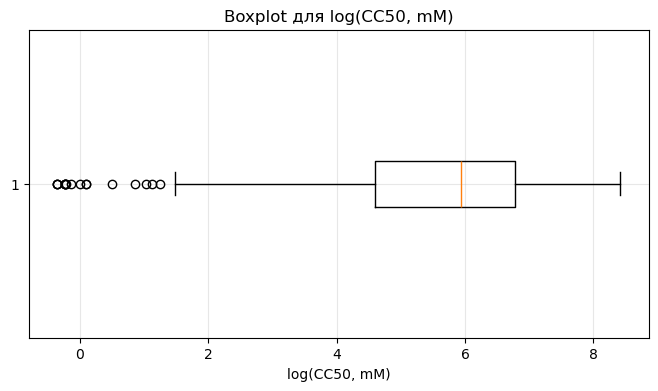

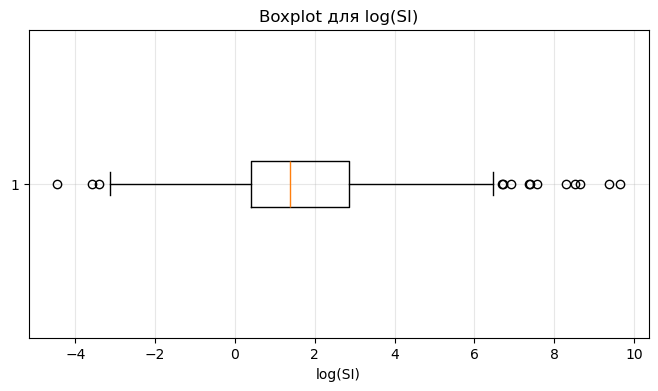

,index,"IC50, mM","CC50, mM",SI,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,qed
663,663,0.016004,249.999200,15620.600000,312.410,1.2854,90.65,2,5,0.691224
434,434,0.021100,250.001758,11848.333333,284.356,0.8069,101.65,3,4,0.669590
492,492,0.003517,19.999437,5687.000000,284.356,0.8069,101.65,3,4,0.669590
92,92,0.393088,1965.439708,5000.000000,254.394,2.4506,26.30,0,2,0.571047
91,91,0.032009,128.090060,4001.700000,312.410,1.2854,90.65,2,5,0.691224
254,254,0.051214,99.999040,1952.562500,312.410,1.2854,90.65,2,5,0.691224
699,699,0.030886,50.001030,1618.888889,291.391,2.6993,69.56,3,3,0.801685
142,142,0.589523,921.129231,1562.500000,271.404,4.4824,21.59,0,2,0.793830
595,595,0.960267,960.267338,1000.000000,312.410,1.2854,90.65,2,5,0.691224
400,400,0.085895,71.201365,828.935484,360.907,2.9766,92.42,3,4,0.769122


In [12]:
# Хвосты и выбросы в таргетах

target_quantiles = train[target_cols].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

display(target_quantiles)

for col in target_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(np.log(train[col]), vert=False)
    plt.title(f"Boxplot для log({col})")
    plt.xlabel(f"log({col})")
    plt.grid(True, alpha=0.3)
    plt.show()

top_si_cols = [
    id_col,
    "IC50, mM",
    "CC50, mM",
    "SI",
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "qed",
]

display(
    train[top_si_cols]
    .sort_values("SI", ascending=False)
    .head(10)
)

In [13]:
# Соединения с низким IC50 и высоким CC50 

ic50_q25 = train["IC50, mM"].quantile(0.25)
cc50_q75 = train["CC50, mM"].quantile(0.75)
si_q75 = train["SI"].quantile(0.75)

candidate_mask = (train["IC50, mM"] <= ic50_q25) & (train["CC50, mM"] >= cc50_q75)
high_si_mask = train["SI"] >= si_q75
low_si_mask = train["SI"] <= 1

print("Порог низкого IC50, 25% квантиль:", ic50_q25)
print("Порог высокого CC50, 75% квантиль:", cc50_q75)
print("Порог высокого SI, 75% квантиль:", si_q75)
print("Кандидатов с низким IC50 и высоким CC50:", candidate_mask.sum())
print("Соединений с SI выше 75% квантиля:", high_si_mask.sum())
print("Соединений с SI <= 1:", low_si_mask.sum())

candidate_cols = [
    id_col,
    "IC50, mM",
    "CC50, mM",
    "SI",
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "qed",
]

display(
    train.loc[candidate_mask, candidate_cols]
    .sort_values("SI", ascending=False)
    .head(15)
)

core_cols = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "HeavyAtomCount",
    "FractionCSP3",
    "qed",
]
core_cols = [col for col in core_cols if col in feature_cols]

comparison = pd.DataFrame({
    "all_median": train[core_cols].median(),
    "good_candidates_median": train.loc[candidate_mask, core_cols].median(),
    "high_si_median": train.loc[high_si_mask, core_cols].median(),
    "low_si_median": train.loc[low_si_mask, core_cols].median(),
})

display(comparison)

Порог низкого IC50, 25% квантиль: 13.222350728062665
Порог высокого CC50, 75% квантиль: 877.5087843465683
Порог высокого SI, 75% квантиль: 17.372462804024785
Кандидатов с низким IC50 и высоким CC50: 14
Соединений с SI выше 75% квантиля: 188
Соединений с SI <= 1: 132


,index,"IC50, mM","CC50, mM",SI,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,qed
92,92,0.393088,1965.439708,5000.000000,254.394,2.4506,26.30,0,2,3,2,0.571047
142,142,0.589523,921.129231,1562.500000,271.404,4.4824,21.59,0,2,3,3,0.793830
595,595,0.960267,960.267338,1000.000000,312.410,1.2854,90.65,2,5,7,1,0.691224
573,573,3.584101,2288.704450,638.571429,195.306,2.2659,32.59,1,2,2,2,0.719980
23,23,3.537791,1965.439708,555.555556,254.394,2.4506,26.30,0,2,3,2,0.571047
341,341,3.930879,1965.439708,500.000000,254.394,2.4506,26.30,0,2,3,2,0.571047
724,724,4.212087,2106.043502,500.000000,237.411,2.9798,12.36,0,1,3,2,0.669233
469,469,6.687877,2388.527425,357.142857,209.333,2.6560,32.59,1,2,3,2,0.712082
427,427,7.715975,2411.242176,312.500000,207.361,4.0737,12.36,0,1,3,2,0.618484
138,138,7.426754,2062.987123,277.777778,242.366,3.8688,25.25,0,2,2,3,0.772532


,all_median,good_candidates_median,high_si_median,low_si_median
MolWt,319.129000,254.394000,294.93100,313.410000
MolLogP,3.434700,3.110750,3.31750,2.981960
TPSA,50.520000,26.300000,38.71500,53.805000
NumHDonors,1.000000,0.000000,1.00000,1.000000
NumHAcceptors,4.000000,2.000000,3.00000,4.000000
NumRotatableBonds,3.000000,3.000000,4.00000,4.000000
RingCount,3.000000,2.000000,3.00000,4.000000
HeavyAtomCount,22.000000,18.000000,21.00000,22.000000
FractionCSP3,0.545455,0.925824,0.75000,0.445906
qed,0.636477,0.680228,0.66959,0.643277


In [14]:
# Дубликаты по признакам и разброс таргетов внутри них

X = train[feature_cols].copy()
X_test = test[feature_cols].copy()

train_hash = pd.util.hash_pandas_object(X, index=False)
test_hash = pd.util.hash_pandas_object(X_test, index=False)

train_with_hash = train.copy()
train_with_hash["feature_hash"] = train_hash

hash_counts = train_with_hash["feature_hash"].value_counts()
duplicate_hashes = hash_counts[hash_counts > 1].index

print("Групп дубликатов в train:", len(duplicate_hashes))
print("Строк train, входящих в группы дубликатов:", hash_counts[hash_counts > 1].sum())
print("Максимальный размер одной группы дубликатов:", hash_counts.max())
print("Дубликатов по признакам в test:", X_test.duplicated().sum())
print("Строк test, полностью совпадающих с train по признакам:", test_hash.isin(set(train_hash)).sum())

dup_group_stats = (
    train_with_hash
    .groupby("feature_hash")
    .agg(
        size=("feature_hash", "size"),
        ic50_min=("IC50, mM", "min"),
        ic50_max=("IC50, mM", "max"),
        cc50_min=("CC50, mM", "min"),
        cc50_max=("CC50, mM", "max"),
        si_min=("SI", "min"),
        si_max=("SI", "max"),
    )
)

dup_group_stats = dup_group_stats[dup_group_stats["size"] > 1].copy()

dup_group_stats["ic50_ratio"] = dup_group_stats["ic50_max"] / dup_group_stats["ic50_min"]
dup_group_stats["cc50_ratio"] = dup_group_stats["cc50_max"] / dup_group_stats["cc50_min"]
dup_group_stats["si_ratio"] = dup_group_stats["si_max"] / dup_group_stats["si_min"]

print()
print("Разброс таргетов внутри групп дубликатов:")
display(dup_group_stats[["size", "ic50_ratio", "cc50_ratio", "si_ratio"]].describe())

display(
    dup_group_stats
    .sort_values("si_ratio", ascending=False)
    .head(10)
)

Групп дубликатов в train: 60
Строк train, входящих в группы дубликатов: 181
Максимальный размер одной группы дубликатов: 16
Дубликатов по признакам в test: 24
Строк test, полностью совпадающих с train по признакам: 68

Разброс таргетов внутри групп дубликатов:


,size,ic50_ratio,cc50_ratio,si_ratio
count,60.000000,60.000000,60.000000,60.000000
mean,3.016667,78.192431,105.245588,9713.908472
std,2.696461,404.659598,488.770743,73069.351552
min,2.000000,1.000000,1.000000,1.000000
25%,2.000000,1.179608,1.000000,1.256017
50%,2.000000,3.140882,1.651305,2.729635
75%,3.000000,16.665244,5.666667,9.327561
max,16.000000,3117.800000,2759.546468,566090.544000


,size,ic50_min,ic50_max,cc50_min,cc50_max,si_min,si_max,ic50_ratio,cc50_ratio,si_ratio
feature_hash,,,,,,,,,,
8138303838662647227,16,0.016004,49.898692,0.700995,1805.081735,0.027594,15620.600000,3117.800000,2575.027397,566090.544000
8017131067727706104,10,0.601637,64.196649,0.700808,499.986777,0.011489,166.208791,106.703297,713.443396,14466.436865
8904135268236528100,13,2.198936,255.928324,1.101516,3039.683222,0.126588,197.898694,116.387337,2759.546468,1563.326112
16808022334083008791,7,0.003517,1.399644,19.999437,250.001758,71.447236,11848.333333,398.000000,12.500440,165.833333
4289302546420235637,3,32.843311,3284.331113,3284.331113,3284.331113,1.000000,100.000000,100.000000,1.000000,100.000000
2297495375936683804,7,1.200799,99.999036,67.997029,99.999036,1.000000,83.277108,83.277108,1.470638,83.277108
12098146955082646701,2,13.312152,1331.215222,754.355292,1331.215222,1.000000,56.666667,100.000000,1.764706,56.666667
7651828125410590146,2,4.912208,81.870132,116.528488,272.900440,1.423333,55.555556,16.666667,2.341920,39.032006
17275549362902625901,2,14.597799,105.781151,87.798356,376.580899,0.830000,25.797101,7.246377,4.289157,31.080845


In [15]:
# Сильно коррелирующие признаки между собой

nunique = train[feature_cols].nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()

non_constant_features = [col for col in feature_cols if col not in constant_cols]
feature_corr = train[non_constant_features].corr(method="spearman").abs()
upper_mask = np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
upper_corr = feature_corr.where(upper_mask)

high_corr_pairs = (
    upper_corr
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_spearman_corr"})
    .sort_values("abs_spearman_corr", ascending=False)
)

print("Пар признаков с abs Spearman corr > 0.95:", (high_corr_pairs["abs_spearman_corr"] > 0.95).sum())
display(high_corr_pairs.head(25))

Пар признаков с abs Spearman corr > 0.95: 83


,feature_1,feature_2,abs_spearman_corr
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
16333,fr_Ar_NH,fr_Nhpyrrole,1.000000
14975,NumAromaticCarbocycles,fr_benzene,1.000000
18216,fr_phenol,fr_phenol_noOrthoHbond,1.000000
18126,fr_nitro_arom,fr_nitro_arom_nonortho,1.000000
16445,fr_COO,fr_COO2,1.000000
1132,MolWt,ExactMolWt,0.999989
5527,Chi1,HeavyAtomCount,0.997770
1131,MolWt,HeavyAtomMolWt,0.995814
1316,HeavyAtomMolWt,ExactMolWt,0.995738


**Что видно:** сильного катастрофического сдвига между train и test по базовым химическим признакам не видно. Test чуть отличается по признакам размера молекулы, но не настолько, чтобы считать выборки из разных миров. Это хороший знак: можно использовать обычную валидацию, но с группами по дубликатам.

In [16]:
# Feature engineering

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["hetero_ratio"] = df["NumHeteroatoms"] / (df["HeavyAtomCount"] + 1)
    df["donor_acceptor_sum"] = df["NumHDonors"] + df["NumHAcceptors"]
    df["donor_acceptor_ratio"] = df["NumHDonors"] / (df["NumHAcceptors"] + 1)
    df["rotatable_per_heavy"] = df["NumRotatableBonds"] / (df["HeavyAtomCount"] + 1)
    df["rings_per_heavy"] = df["RingCount"] / (df["HeavyAtomCount"] + 1)
    df["aromatic_ratio"] = df["NumAromaticRings"] / (df["RingCount"] + 1)
    df["tpsa_per_heavy"] = df["TPSA"] / (df["HeavyAtomCount"] + 1)
    df["mol_logp_per_heavy"] = df["MolLogP"] / (df["HeavyAtomCount"] + 1)
    df["mol_mr_per_molwt"] = df["MolMR"] / (df["MolWt"] + 1)

    fr_cols = [col for col in df.columns if col.startswith("fr_")]
    vsa_cols = [col for col in df.columns if "VSA" in col]
    estate_cols = [col for col in df.columns if "EState" in col]

    df["fr_total"] = df[fr_cols].sum(axis=1)
    df["fr_nonzero_count"] = (df[fr_cols] > 0).sum(axis=1)
    df["vsa_total"] = df[vsa_cols].sum(axis=1)
    df["vsa_nonzero_count"] = (df[vsa_cols] > 0).sum(axis=1)
    df["estate_abs_sum"] = df[estate_cols].abs().sum(axis=1)

    return df

X_base = train[feature_cols].copy()
X_test_base = test[feature_cols].copy()

X_fe = add_features(X_base)
X_test_fe = add_features(X_test_base)

new_cols = [col for col in X_fe.columns if col not in X_base.columns]

print("Было признаков:", X_base.shape[1])
print("Стало признаков:", X_fe.shape[1])
print("Новых признаков:", len(new_cols))

display(X_fe[new_cols].head())

Было признаков: 210
Стало признаков: 224
Новых признаков: 14


,hetero_ratio,donor_acceptor_sum,donor_acceptor_ratio,rotatable_per_heavy,rings_per_heavy,aromatic_ratio,tpsa_per_heavy,mol_logp_per_heavy,mol_mr_per_molwt,fr_total,fr_nonzero_count,vsa_total,vsa_nonzero_count,estate_abs_sum
0,0.214286,3,0.000,0.071429,0.142857,0.333333,0.890714,0.155100,0.290722,6,6,354.540880,29,119.756907
1,0.291667,7,0.600,0.166667,0.083333,0.333333,3.850833,0.124025,0.257140,8,8,630.046320,38,235.698958
2,0.125000,4,0.250,0.291667,0.166667,0.200000,1.270417,0.159513,0.297664,8,6,601.067594,35,194.732425
3,0.419355,8,0.125,0.161290,0.096774,0.750000,4.215484,0.155568,0.225735,22,13,764.380303,36,314.052555
4,0.083333,2,0.500,0.000000,0.333333,0.000000,2.168333,0.159492,0.296154,1,1,288.454962,16,99.043602
